# Delta Hedging Under Model Mismatch: A SABR vs. Black–Scholes Study

## 1. Objective and Motivation

This project calibrates a SABR stochastic volatility model to an observed AAPL option implied volatility smile, then evaluates the impact of model misspecification on delta hedging performance.

The motivation behind this project is in quantitative trading and derivatives modeling, pricing accuracy is important, but hedging robustness is often even more important. This notebook demonstrates how volatility model calibration affects hedging error distributions in practice.

The main goal is to show how hedging performance changes when volatility is modeled dynamically under SABR but hedged under a simpler Black–Scholes assumption.

In [93]:
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from scipy.optimize import least_squares
from scipy.stats import norm

warnings.filterwarnings("ignore")
np.set_printoptions(suppress=True, precision=6)

In [ ]:
SYMBOL = "AAPL"
R = 0.04
BETA = 0.5
STRIKE_SPAN = 0.15
MIN_DAYS = 45
MAX_DAYS = 90

N_PATHS = 5000
N_STEPS = 5
SEED = 42

OTM_PUT_PCT = 0.90   

## 2. Black–Scholes utilities for a put option

The helper functions compute:
- the European put price
- the European put delta

They will be used later for pricing and hedging.

In [95]:
def bs_put_price(S, K, T, r, sigma):
    if T <= 0:
        return max(K - S, 0.0)
    sigma = max(float(sigma), 1e-12)
    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return K * math.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def bs_put_delta(S, K, T, r, sigma):
    if T <= 0:
        return -1.0 if S < K else 0.0
    sigma = max(float(sigma), 1e-12)
    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    return norm.cdf(d1) - 1.0

## 3. Hagan SABR implied volatility approximation

This function returns the SABR lognormal implied volatility approximation given the following inputs:

- forward price
- strike
- time to maturity
- SABR parameters alpha, beta, rho, nu

In [96]:
def sabr_hagan_lognormal_iv(F, K, T, alpha, beta, rho, nu):
    F = max(float(F), 1e-12)
    K = max(float(K), 1e-12)
    T = max(float(T), 1e-12)
    alpha = max(float(alpha), 1e-12)
    nu = max(float(nu), 1e-12)

    if abs(F - K) < 1e-12:
        FK_beta = F ** (1.0 - beta)
        term1 = alpha / FK_beta
        term2 = (
            ((1.0 - beta) ** 2 / 24.0) * (alpha**2) / (F ** (2.0 - 2.0 * beta))
            + (rho * beta * nu * alpha) / (4.0 * (F ** (1.0 - beta)))
            + ((2.0 - 3.0 * rho * rho) * nu * nu / 24.0)
        )
        return max(term1 * (1.0 + term2 * T), 1e-12)

    lnFK = math.log(F / K)
    FK = F * K
    one_minus_beta = 1.0 - beta

    z = (nu / alpha) * (FK ** (0.5 * one_minus_beta)) * lnFK
    xz_num = math.sqrt(1.0 - 2.0 * rho * z + z * z) + z - rho
    xz_den = 1.0 - rho
    xz = math.log(xz_num / xz_den)

    denom = (FK ** (0.5 * one_minus_beta)) * (
        1.0
        + (one_minus_beta ** 2 / 24.0) * (lnFK ** 2)
        + (one_minus_beta ** 4 / 1920.0) * (lnFK ** 4)
    )

    A = ((one_minus_beta) ** 2 / 24.0) * (alpha ** 2) / (FK ** one_minus_beta)
    B = (rho * beta * nu * alpha) / (4.0 * (FK ** (one_minus_beta / 2.0)))
    C = (2.0 - 3.0 * rho * rho) * (nu ** 2) / 24.0

    if abs(xz) < 1e-14:
        return np.nan

    sigma = (alpha / denom) * (z / xz) * (1.0 + (A + B + C) * T)
    return max(float(sigma), 1e-12)

## 4. Load live option smile from Yahoo Finance using put options

This function:
- gets the latest stock price
- finds a suitable option expiry
- loads the put chain
- filters strikes near the current spot
- extracts implied volatilities
- chooses an OTM put strike
- estimates a Black–Scholes put premium

In [97]:
def load_live_smile(symbol="AAPL", r=0.04, strike_span=0.15, min_days=45, max_days=90, otm_put_pct=0.90):
    tk = yf.Ticker(symbol)
    hist = tk.history(period="1d")
    if hist.empty:
        raise ValueError("Could not fetch spot price from yfinance.")

    spot = float(hist["Close"].iloc[-1])
    today = pd.Timestamp.today().normalize()
    expiries = tk.options

    if not expiries:
        raise ValueError("No option expiries returned by yfinance.")

    candidates = []
    for e in expiries:
        d = pd.Timestamp(e)
        days = (d - today).days
        if min_days <= days <= max_days:
            candidates.append((days, e))

    if not candidates:
        expiry = expiries[0]
        print(f"Warning: no expiry found in [{min_days}, {max_days}] days, using {expiry}")
    else:
        expiry = sorted(candidates, key=lambda x: x[0])[0][1]

    puts = tk.option_chain(expiry).puts.copy()
    puts = puts[
        (puts["strike"] >= spot * (1.0 - strike_span)) &
        (puts["strike"] <= spot * (1.0 + strike_span)) &
        (puts["impliedVolatility"] > 0)
    ].sort_values("strike")

    if len(puts) < 5:
        raise ValueError("Not enough put strikes with valid implied volatility.")

    T = max((pd.Timestamp(expiry) - today).days, 1) / 365.0
    strikes = puts["strike"].to_numpy(float)
    iv = puts["impliedVolatility"].to_numpy(float)

    target_strike = spot * otm_put_pct
    otm_candidates = strikes[strikes < spot]
    if len(otm_candidates) == 0:
        raise ValueError("No OTM put strikes found below spot.")

    otm_put_strike = float(otm_candidates[np.argmin(np.abs(otm_candidates - target_strike))])
    otm_idx = int(np.argmin(np.abs(strikes - otm_put_strike)))
    otm_put_iv = float(iv[otm_idx])

    premium = bs_put_price(spot, otm_put_strike, T, r, otm_put_iv)

    return spot, T, expiry, strikes, iv, otm_put_strike, otm_put_iv, premium

## 5. Calibrate the SABR model

This function fits the SABR parameters:
- alpha
- rho
- nu

The beta value is fixed. The calibration minimizes the difference between market implied volatilities and SABR model implied volatilities.

In [98]:
def calibrate_sabr_hagan(F, T, strikes, market_iv, beta):
    F = float(F)
    T = float(T)
    strikes = np.asarray(strikes, dtype=float)
    iv = np.asarray(market_iv, dtype=float)

    atm_idx = int(np.argmin(np.abs(strikes - F)))
    atm_iv = float(iv[atm_idx])

    alpha0 = max(1e-4, atm_iv * (F ** (1.0 - beta)))
    x0 = np.array([alpha0, 0.0, 0.5], dtype=float)

    lb = np.array([1e-6, -0.999, 1e-6], dtype=float)
    ub = np.array([5.0, 0.999, 5.0], dtype=float)

    def residuals(x):
        a, r, n = x
        model = np.array(
            [sabr_hagan_lognormal_iv(F, k, T, a, beta, r, n) for k in strikes],
            dtype=float
        )
        return model - iv

    res = least_squares(residuals, x0=x0, bounds=(lb, ub), max_nfev=5000)
    alpha_hat, rho_hat, nu_hat = map(float, res.x)
    return alpha_hat, rho_hat, nu_hat

## 6. Simulate SABR spot paths

This function simulates stock price paths under SABR-style dynamics.

It evolves:
- the stock price
- the volatility state

using correlated shocks.

In [99]:
def simulate_sabr_spot_paths(S0, alpha0, beta, rho, nu, T, n_steps, n_paths, r=0.0, seed=42):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    sqrt_dt = math.sqrt(dt)

    S = np.full((n_paths, n_steps + 1), S0, dtype=float)
    a = np.full((n_paths, n_steps + 1), alpha0, dtype=float)

    z1 = rng.standard_normal((n_paths, n_steps))
    z2 = rng.standard_normal((n_paths, n_steps))

    w1 = z1
    w2 = rho * z1 + math.sqrt(max(1.0 - rho * rho, 0.0)) * z2

    for t in range(n_steps):
        St = np.maximum(S[:, t], 1e-12)
        at = np.maximum(a[:, t], 1e-12)

        dS = r * St * dt + at * (St ** beta) * sqrt_dt * w1[:, t]
        da = nu * at * sqrt_dt * w2[:, t]

        S[:, t + 1] = np.maximum(St + dS, 1e-12)
        a[:, t + 1] = np.maximum(at + da, 1e-12)

    return S

## 7. Run the hedging experiment for an OTM put

This function compares two hedging strategies:

1. using SABR-implied volatility inside Black–Scholes put delta
2. using a flat Black–Scholes put delta with the selected OTM put volatility

For each simulated path, it tracks:
- the cash account
- the stock hedge position
- the final hedging P&L

In [100]:
def run_hedge_experiment(spot, r, T, K, put_iv, premium, beta, sabr_params,
                         n_paths=5000, n_steps=10, seed=42):
    alpha_hat, rho_hat, nu_hat = sabr_params

    S_paths = simulate_sabr_spot_paths(
        S0=spot,
        alpha0=alpha_hat,
        beta=beta,
        rho=rho_hat,
        nu=nu_hat,
        T=T,
        n_steps=n_steps,
        n_paths=n_paths,
        r=r,
        seed=seed
    )

    dt = T / n_steps
    pnl_sabr = np.zeros(n_paths)
    pnl_bs = np.zeros(n_paths)

    def delta_sabr(St, tau):
        if tau <= 0:
            return -1.0 if St < K else 0.0
        F = St * math.exp(r * tau)
        iv = sabr_hagan_lognormal_iv(F, K, tau, alpha_hat, beta, rho_hat, nu_hat)
        iv = max(iv, 1e-8)
        return bs_put_delta(St, K, tau, r, iv)

    def delta_bs(St, tau):
        if tau <= 0:
            return -1.0 if St < K else 0.0
        return bs_put_delta(St, K, tau, r, put_iv)

    for i in range(n_paths):
        cash_sabr = premium
        cash_bs = premium
        pos_sabr = 0.0
        pos_bs = 0.0

        for step in range(n_steps):
            t = step * dt
            tau = T - t
            St = float(S_paths[i, step])

            cash_sabr *= math.exp(r * dt)
            cash_bs *= math.exp(r * dt)

            d_sabr = delta_sabr(St, tau)
            d_bs = delta_bs(St, tau)

            cash_sabr -= (d_sabr - pos_sabr) * St
            cash_bs -= (d_bs - pos_bs) * St

            pos_sabr = d_sabr
            pos_bs = d_bs

        ST = float(S_paths[i, -1])
        payoff = max(K - ST, 0.0)

        cash_sabr += pos_sabr * ST - payoff
        cash_bs += pos_bs * ST - payoff

        pnl_sabr[i] = cash_sabr
        pnl_bs[i] = cash_bs

    return pnl_sabr, pnl_bs

## 8. Summarize the hedging P&L

This helper prints summary statistics for the terminal P&L distribution.

In [101]:
def summarize_pnl(x, name):
    x = np.asarray(x, dtype=float)
    print(f"\n{name}")
    print(f" mean : {np.mean(x): .6f}")
    print(f" std  : {np.std(x, ddof=1): .6f}")
    print(f" p05  : {np.quantile(x, 0.05): .6f}")
    print(f" p50  : {np.quantile(x, 0.50): .6f}")
    print(f" p95  : {np.quantile(x, 0.95): .6f}")

## 9. Load data, fit SABR, and run the experiment

This cell performs the full workflow:
- load the live put smile
- choose an OTM put
- compute the forward price
- calibrate the SABR model
- run the hedging experiment
- print summary statistics

In [102]:
spot, T, expiry, strikes, iv, otm_put_strike, otm_put_iv, premium = load_live_smile(
    symbol=SYMBOL,
    r=R,
    strike_span=STRIKE_SPAN,
    min_days=MIN_DAYS,
    max_days=MAX_DAYS,
    otm_put_pct=OTM_PUT_PCT
)

print("Loaded live AAPL put smile")
print(f" Spot           : {spot:.4f}")
print(f" Expiry         : {expiry}")
print(f" T              : {T:.4f}")
print(f" OTM put strike : {otm_put_strike:.4f}")
print(f" OTM put IV     : {otm_put_iv:.4f}")
print(f" OTM put premium: {premium:.4f}")
print(f" # strikes      : {len(strikes)}")

F0 = spot * math.exp(R * T)

alpha_hat, rho_hat, nu_hat = calibrate_sabr_hagan(
    F=F0,
    T=T,
    strikes=strikes,
    market_iv=iv,
    beta=BETA
)

print("\nSABR parameters")
print(f" beta  = {BETA:.3f}")
print(f" alpha = {alpha_hat:.6f}")
print(f" rho   = {rho_hat:.6f}")
print(f" nu    = {nu_hat:.6f}")

pnl_sabr, pnl_bs = run_hedge_experiment(
    spot=spot,
    r=R,
    T=T,
    K=otm_put_strike,
    put_iv=otm_put_iv,
    premium=premium,
    beta=BETA,
    sabr_params=(alpha_hat, rho_hat, nu_hat),
    n_paths=N_PATHS,
    n_steps=N_STEPS,
    seed=SEED
)

summarize_pnl(pnl_sabr, "Hedging P&L: SABR delta (OTM put)")
summarize_pnl(pnl_bs, "Hedging P&L: BS flat-vol delta (OTM put)")

Loaded live AAPL put smile
 Spot           : 254.0401
 Expiry         : 2026-05-15
 T              : 0.1397
 OTM put strike : 230.0000
 OTM put IV     : 0.3366
 OTM put premium: 3.4238
 # strikes      : 15

SABR parameters
 beta  = 0.500
 alpha = 3.895708
 rho   = -0.372496
 nu    = 2.520110

Hedging P&L: SABR delta (OTM put)
 mean :  0.398877
 std  :  6.091599
 p05  : -8.602132
 p50  :  1.484764
 p95  :  5.587819

Hedging P&L: BS flat-vol delta (OTM put)
 mean :  0.410757
 std  :  5.923109
 p05  : -8.908358
 p50  :  1.445584
 p95  :  5.752187


## 10. Plot the market put smile and fitted SABR smile

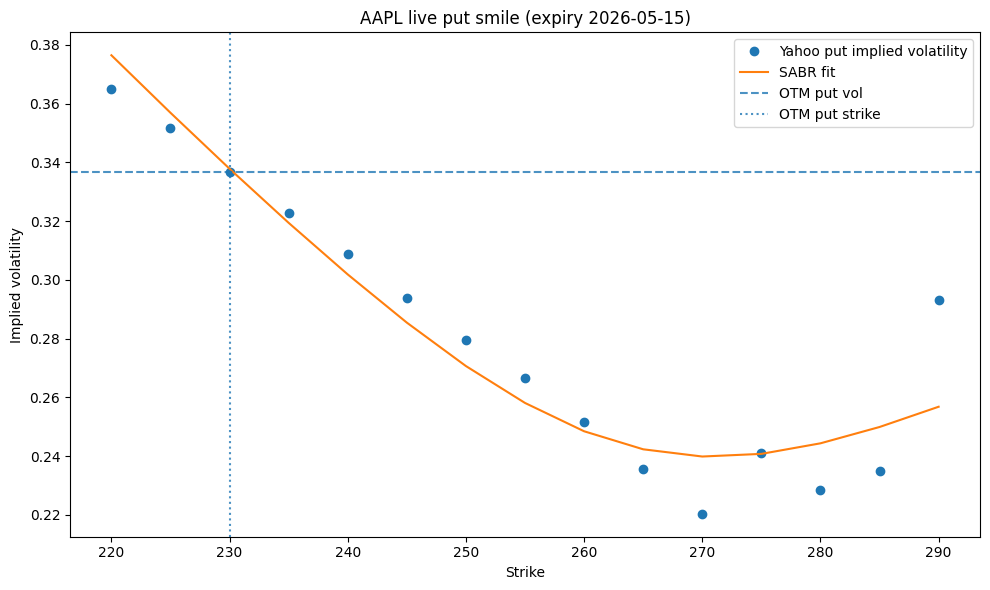

In [103]:
model_iv = np.array([
    sabr_hagan_lognormal_iv(F0, k, T, alpha_hat, BETA, rho_hat, nu_hat)
    for k in strikes
], dtype=float)

plt.figure(figsize=(10, 6))
plt.plot(strikes, iv, "o", label="Yahoo put implied volatility")
plt.plot(strikes, model_iv, "-", label="SABR fit")
plt.axhline(otm_put_iv, linestyle="--", alpha=0.8, label="OTM put vol")
plt.axvline(otm_put_strike, linestyle=":", alpha=0.8, label="OTM put strike")
plt.title(f"{SYMBOL} live put smile (expiry {expiry})")
plt.xlabel("Strike")
plt.ylabel("Implied volatility")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Plot the terminal hedging P&L distributions

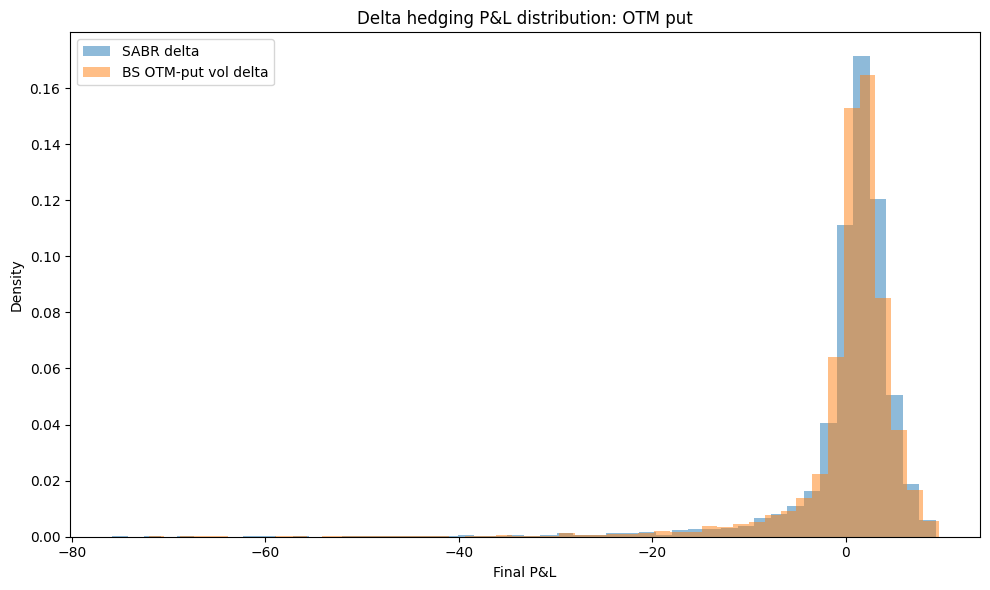

In [104]:
plt.figure(figsize=(10, 6))
plt.hist(pnl_sabr, bins=50, alpha=0.5, density=True, label="SABR delta")
plt.hist(pnl_bs, bins=50, alpha=0.5, density=True, label="BS OTM-put vol delta")
plt.title("Delta hedging P&L distribution: OTM put")
plt.xlabel("Final P&L")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Key takeaways and extensions

### We record few key takeaways from this project:
1. We used live AAPL put data to build an implied volatility smile from market prices.
2. We calibrated a SABR model to the smile instead of assuming one flat volatility.
3. We compared SABR-based delta hedging with Black–Scholes flat-vol hedging for an OTM put, where model mismatch is often more visible.

### Potential extensions for further research:
1. Move the strike further out of the money, for example from 95% spot to 90% spot, and compare how the hedging error changes.
2. Add transaction costs and test different hedge rebalancing frequencies such as daily versus intraday.
3. Compare Black–Scholes flat-vol hedging with re-marked implied-vol hedging or a more fully SABR-consistent hedge.